In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline



# Step 1: Generate Synthetic Data (Mimicking a Real-World Scenario)

In [ ]:
np.random.seed(42)
n_samples = 200
# Generating features: size in square feet, number of rooms, and age of the house
size = np.random.randint(500, 4000, n_samples)
rooms = np.random.randint(1, 7, n_samples)
age = np.random.randint(1, 50, n_samples)
# Random noise for price
noise = np.random.randn(n_samples) * 10000

# Generating target variable (price) using a nonlinear relationship
price = 30000 + (size * 50) + (rooms * 10000) - (age * 300) + noise

# Creating a DataFrame
data = pd.DataFrame({'Size': size, 'Rooms': rooms, 'Age': age, 'Price': price})






In [ ]:
data

,Size,Rooms,Age,Price
0,3674,4,21,247190.984060
1,1360,4,32,129573.273833
2,1794,6,23,185576.648958
3,1630,6,33,155684.286112
4,1595,3,3,144320.973812
...,...,...,...,...
195,3560,5,10,241172.002690
196,3193,3,37,217811.775475
197,1295,4,9,151144.166405
198,1551,1,24,96364.324262


# Step 2: Data Preprocessing


In [ ]:
# Exploring the dataset
print(data.head())

# Checking for missing values
print("\nMissing values in the dataset:")
print(data.isnull().sum())


   Size  Rooms  Age          Price
0  3674      4   21  247190.984060
1  1360      4   32  129573.273833
2  1794      6   23  185576.648958
3  1630      6   33  155684.286112
4  1595      3    3  144320.973812

Missing values in the dataset:
Size     0
Rooms    0
Age      0
Price    0
dtype: int64



# Step 3: Split the Data into Training and Testing Sets


In [ ]:
X = data[['Size', 'Rooms', 'Age']]
y = data['Price']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Build Simple Linear Regression Model (using Size only for demonstration)


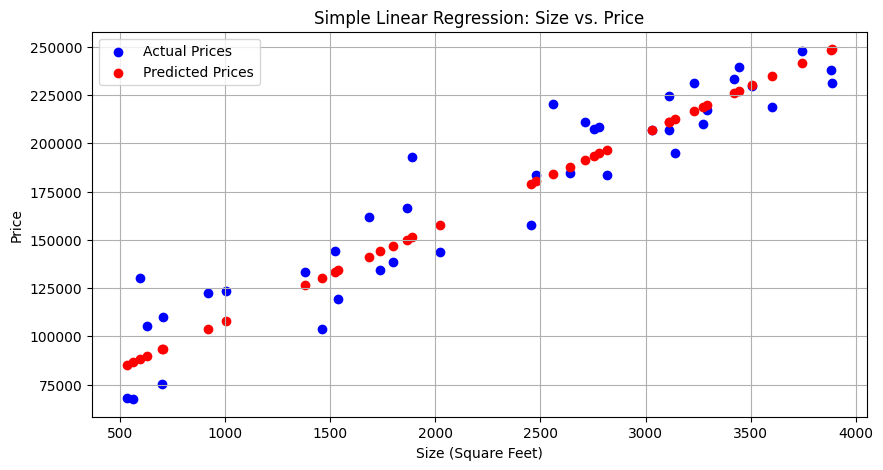

In [ ]:
# Fitting the model
linear_model = LinearRegression()
linear_model.fit(X_train[['Size']], y_train)

# Predicting on the test set
y_pred_linear = linear_model.predict(X_test[['Size']])

# Evaluating the Linear Regression Model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

# Plotting Simple Linear Regression Results
plt.figure(figsize=(10, 5))
plt.scatter(X_test['Size'], y_test, color='blue', label='Actual Prices')
plt.scatter(X_test['Size'], y_pred_linear, color='red', label='Predicted Prices')
plt.title('Simple Linear Regression: Size vs. Price')
plt.xlabel('Size (Square Feet)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Step 5: Build Polynomial Regression Model

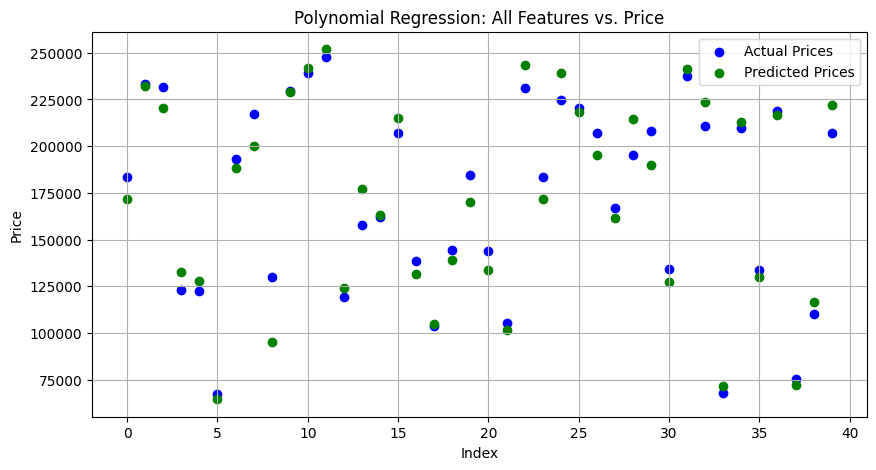

In [ ]:
# Using Polynomial Features with Degree 2
poly_model = make_pipeline(StandardScaler(), PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y_train)

# Predicting on the test set
y_pred_poly = poly_model.predict(X_test)

# Evaluating the Polynomial Regression Model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

# Plotting Polynomial Regression Results
plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual Prices')
plt.scatter(range(len(y_test)), y_pred_poly, color='green', label='Predicted Prices')
plt.title('Polynomial Regression: All Features vs. Price')
plt.xlabel('Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()



# Step 6: Compare the Models

In [ ]:

# Displaying evaluation metrics
results = pd.DataFrame({
    'Model': ['Linear Regression (Size only)', 'Polynomial Regression (All features)'],
    'MSE': [mse_linear, mse_poly],
    'R-squared': [r2_linear, r2_poly]
})

# Display the results
print("\nModel Evaluation Summary:")
print(results)


Model Evaluation Summary:
                                  Model           MSE  R-squared
0         Linear Regression (Size only)  3.031335e+08   0.886178
1  Polynomial Regression (All features)  1.178213e+08   0.955760


# Step 7: Feature Importance for Polynomial Regression


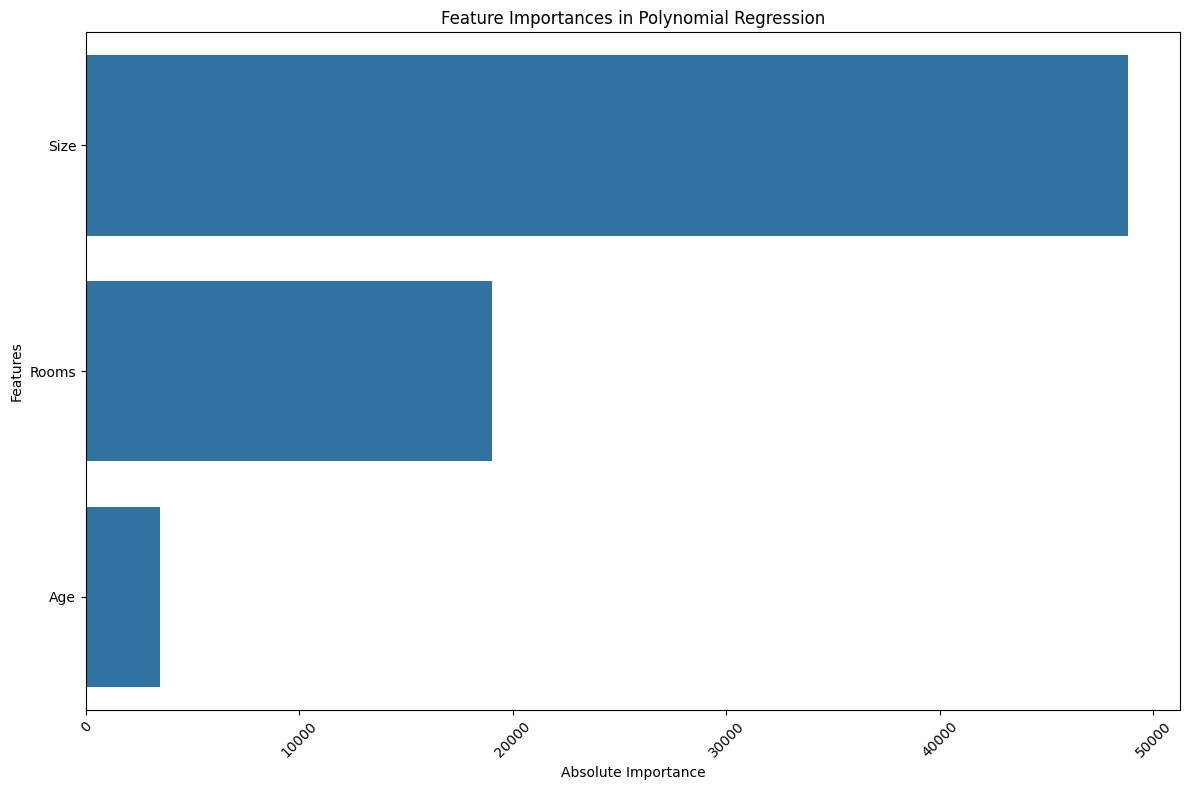


Feature Importances:
  feature    importance
1    Size  48812.450287
2   Rooms  19025.199507
3     Age   3479.324010


In [ ]:
poly_model.fit(X_train, y_train)
feature_importance = poly_model.named_steps['linearregression'].coef_
feature_names = poly_model.named_steps['polynomialfeatures'].get_feature_names_out(X.columns)

importance_df = pd.DataFrame({'feature': feature_names, 'importance': abs(feature_importance)})
importance_df = importance_df.sort_values('importance', ascending=False).head(3)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Feature Importances in Polynomial Regression')
plt.xlabel('Absolute Importance')
plt.ylabel('Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nFeature Importances:")
print(importance_df)